In [ ]:
!pip install datasets

In [ ]:
from datasets import load_dataset

dataset = load_dataset("commonsense_qa")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/1.25M [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/160k [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/151k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/9741 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/1221 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1140 [00:00<?, ? examples/s]

In [ ]:
print(dataset)
print(dataset['train'][0])

DatasetDict({
    train: Dataset({
        features: ['id', 'question', 'question_concept', 'choices', 'answerKey'],
        num_rows: 9741
    })
    validation: Dataset({
        features: ['id', 'question', 'question_concept', 'choices', 'answerKey'],
        num_rows: 1221
    })
    test: Dataset({
        features: ['id', 'question', 'question_concept', 'choices', 'answerKey'],
        num_rows: 1140
    })
})
{'id': '075e483d21c29a511267ef62bedc0461', 'question': 'The sanctions against the school were a punishing blow, and they seemed to what the efforts the school had made to change?', 'question_concept': 'punishing', 'choices': {'label': ['A', 'B', 'C', 'D', 'E'], 'text': ['ignore', 'enforce', 'authoritarian', 'yell at', 'avoid']}, 'answerKey': 'A'}


In [ ]:
dataset = load_dataset("commonsense_qa", split="train[:1000]")

In [ ]:
!pip install transformers accelerate

In [ ]:
from transformers import AutoTokenizer, AutoModelForCausalLM
import torch

model_name = "gpt2-medium"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(model_name)

model.eval()

config.json:   0%|          | 0.00/718 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.52G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/292 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2-medium
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...23}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

GPT2LMHeadModel(
  (transformer): GPT2Model(
    (wte): Embedding(50257, 1024)
    (wpe): Embedding(1024, 1024)
    (drop): Dropout(p=0.1, inplace=False)
    (h): ModuleList(
      (0-23): 24 x GPT2Block(
        (ln_1): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
        (attn): GPT2Attention(
          (c_attn): Conv1D(nf=3072, nx=1024)
          (c_proj): Conv1D(nf=1024, nx=1024)
          (attn_dropout): Dropout(p=0.1, inplace=False)
          (resid_dropout): Dropout(p=0.1, inplace=False)
        )
        (ln_2): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
        (mlp): GPT2MLP(
          (c_fc): Conv1D(nf=4096, nx=1024)
          (c_proj): Conv1D(nf=1024, nx=4096)
          (act): NewGELUActivation()
          (dropout): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
  )
  (lm_head): Linear(in_features=1024, out_features=50257, bias=False)
)

In [ ]:
def log_prob(prompt, completion):

    text = prompt + " " + completion
    inputs = tokenizer(text, return_tensors="pt")

    input_ids = inputs["input_ids"]

    with torch.no_grad():
        outputs = model(input_ids)

    logits = outputs.logits[:, :-1]
    targets = input_ids[:, 1:]

    log_probs = torch.nn.functional.log_softmax(logits, dim=-1)

    total_log_prob = 0

    for i in range(targets.shape[1]):
        token_id = targets[0, i]
        total_log_prob += log_probs[0, i, token_id]

    return total_log_prob.item()

In [ ]:
example = dataset[0]

question = example["question"]
choices = example["choices"]["text"]
labels = example["choices"]["label"]

scores = []

for ans in choices:

    lm = log_prob(question, ans)
    unc = log_prob("Answer:", ans)
    pmi = lm - unc

    scores.append({
        "answer": ans,
        "lm": lm,
        "unc": unc,
        "pmi": pmi
    })

scores

[{'answer': 'ignore',
  'lm': -114.59272766113281,
  'unc': -13.704710960388184,
  'pmi': -100.88801670074463},
 {'answer': 'enforce',
  'lm': -117.30815887451172,
  'unc': -14.304152488708496,
  'pmi': -103.00400638580322},
 {'answer': 'authoritarian',
  'lm': -118.55751037597656,
  'unc': -16.623825073242188,
  'pmi': -101.93368530273438},
 {'answer': 'yell at',
  'lm': -120.95497131347656,
  'unc': -18.135217666625977,
  'pmi': -102.81975364685059},
 {'answer': 'avoid',
  'lm': -115.03958129882812,
  'unc': -13.392195701599121,
  'pmi': -101.647385597229}]

In [ ]:
import numpy as np

lm_choice = choices[np.argmax([s["lm"] for s in scores])]
pmi_choice = choices[np.argmax([s["pmi"] for s in scores])]

lm_margins = []
pmi_margins = []

In [ ]:
import numpy as np

N = 200

lm_correct = 0
pmi_correct = 0
unc_correct = 0

disagreements = []
lm_wrong_pmi_correct = []

# Confidence analysis containers
lm_correct_margins = []
lm_wrong_margins = []

scatter_lm = []
scatter_pmi = []

for i in range(N):

    example = dataset[i]

    question = example["question"]
    choices = example["choices"]["text"]
    labels = example["choices"]["label"]
    correct = example["answerKey"]

    prompt = f"Question: {question}\nAnswer:"

    lm_scores = []
    unc_scores = []
    pmi_scores = []

    for ans in choices:

        lm = log_prob(prompt, ans)
        unc = log_prob("Answer:", ans)
        pmi = lm - unc

        lm_scores.append(lm)
        unc_scores.append(unc)
        pmi_scores.append(pmi)

    lm_idx = np.argmax(lm_scores)
    pmi_idx = np.argmax(pmi_scores)
    unc_idx = np.argmax(unc_scores)

    # Accuracy
    if labels[lm_idx] == correct:
        lm_correct += 1
    else:
        # store LM margin for wrong predictions
        lm_sorted = sorted(lm_scores)
        lm_margin = lm_sorted[-1] - lm_sorted[-2]
        lm_wrong_margins.append(lm_margin)

    if labels[pmi_idx] == correct:
        pmi_correct += 1

    if labels[unc_idx] == correct:
        unc_correct += 1

    # LM correct margin
    if labels[lm_idx] == correct:
        lm_sorted = sorted(lm_scores)
        lm_margin = lm_sorted[-1] - lm_sorted[-2]
        lm_correct_margins.append(lm_margin)

    # disagreements
    if lm_idx != pmi_idx:

        disagreements.append({
            "question": question,
            "lm": choices[lm_idx],
            "pmi": choices[pmi_idx],
            "correct": correct
        })

        scatter_lm.append(lm_scores[lm_idx])
        scatter_pmi.append(pmi_scores[pmi_idx])

    # store PMI fixes
    if labels[lm_idx] != correct and labels[pmi_idx] == correct:

        lm_wrong_pmi_correct.append({
            "question": question,
            "choices": choices,
            "labels": labels,
            "correct": correct,
            "lm_choice": labels[lm_idx],
            "pmi_choice": labels[pmi_idx]
        })

In [ ]:
print("LM accuracy:", lm_correct / N)
print("PMI accuracy:", pmi_correct / N)
print("UNC accuracy:", unc_correct / N)

print("LM vs PMI disagreements:", len(disagreements))

LM accuracy: 0.305
PMI accuracy: 0.365
UNC accuracy: 0.205
LM vs PMI disagreements: 135


In [ ]:
from IPython.core.display import display, HTML

# Results with highlight for best
results = [
    {"Method": "LM", "Accuracy": 0.305},
    {"Method": "PMI", "Accuracy": 0.365},
    {"Method": "UNC", "Accuracy": 0.205}
]

# Build HTML table
html = """
<style>
table.custom-table {
    border-collapse: collapse;
    font-family: Arial, sans-serif;
    font-size: 16px;
    width: 40%;
}
table.custom-table th, table.custom-table td {
    border: 1px solid #555;
    padding: 8px 12px;
    text-align: center;
}
table.custom-table th {
    background-color: #2F4F4F;
    color: white;
}
table.custom-table td.best {
    background-color: #8FBC8F;  /* light green highlight */
    font-weight: bold;
}
</style>
<table class="custom-table">
<tr>
<th>Method</th>
<th>Accuracy</th>
</tr>
"""

for row in results:
    accuracy_pct = f"{row['Accuracy']*100:.1f}%"
    best_class = "best" if row['Accuracy'] == max(r['Accuracy'] for r in results) else ""
    html += f"<tr><td>{row['Method']}</td><td class='{best_class}'>{accuracy_pct}</td></tr>"

html += "</table>"

display(HTML(html))

Method,Accuracy
LM,30.5%
PMI,36.5%
UNC,20.5%


In [ ]:
for d in disagreements[:5]:
    print("\nQuestion:", d["question"])
    print("LM answer:", d["lm"])
    print("PMI answer:", d["pmi"])
    print("Correct:", d["correct"])


Question: The sanctions against the school were a punishing blow, and they seemed to what the efforts the school had made to change?
LM answer: ignore
PMI answer: authoritarian
Correct: A

Question: Sammy wanted to go to where the people were.  Where might he go?
LM answer: the desert
PMI answer: populated areas
Correct: B

Question: To locate a choker not located in a jewelry box or boutique where would you go?
LM answer: jewelry box
PMI answer: jewlery box
Correct: A

Question: The fox walked from the city into the forest, what was it looking for?
LM answer: storybook
PMI answer: pretty flowers.
Correct: C

Question: The forgotten leftovers had gotten quite old, he found it covered in mold in the back of his what?
LM answer: coach
PMI answer: breadbox
Correct: B


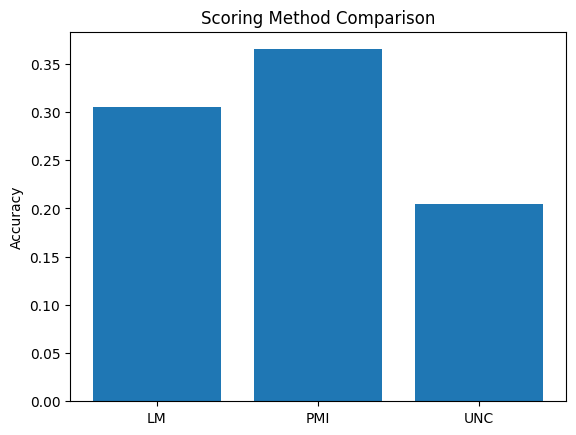

In [ ]:
import matplotlib.pyplot as plt

methods = ["LM", "PMI", "UNC"]
scores = [
    lm_correct / N,
    pmi_correct / N,
    unc_correct / N
]

plt.bar(methods, scores)
plt.ylabel("Accuracy")
plt.title("Scoring Method Comparison")
plt.show()

In [ ]:
import random

examples = random.sample(lm_wrong_pmi_correct, min(20, len(lm_wrong_pmi_correct)))

for i, ex in enumerate(examples):

    print("\n==============================")
    print(f"Example {i+1}")
    print("==============================")

    print("Question:")
    print(ex["question"])
    print()

    print("Choices:")
    for label, choice in zip(ex["labels"], ex["choices"]):
        print(f"{label}: {choice}")

    print()
    print("Correct:", ex["correct"])
    print("LM Prediction:", ex["lm_choice"])
    print("PMI Prediction:", ex["pmi_choice"])


Example 1
Question:
Where would you expect to find a pizzeria while shopping?

Choices:
A: chicago
B: street
C: little italy
D: food court
E: capital cities

Correct: D
LM Prediction: B
PMI Prediction: D

Example 2
Question:
You can share files with someone if you have a connection to a what?

Choices:
A: freeway
B: radio
C: wires
D: computer network
E: electrical circuit

Correct: D
LM Prediction: B
PMI Prediction: D

Example 3
Question:
John and Jane were a couple.  They were dating for a while and wanted to be together for even longer. For this reason, they did what?

Choices:
A: make sex
B: plan to marry
C: dance
D: electrical circuit
E: row about

Correct: B
LM Prediction: C
PMI Prediction: B

Example 4
Question:
James complained that Alexa's electric guitar was too loud and he couldn't get any work done at home,  so she decided that she should get an acoustic guitar.  Where might she look for one?

Choices:
A: house
B: music shop
C: studio
D: storage
E: closet

Correct: B
LM Pre

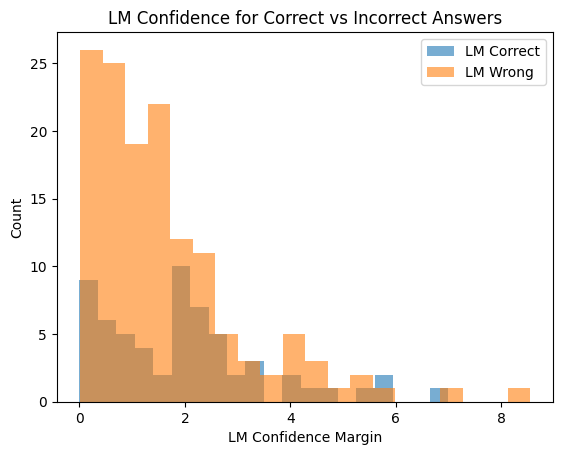

In [ ]:
import matplotlib.pyplot as plt

plt.hist(lm_correct_margins, bins=20, alpha=0.6, label="LM Correct")
plt.hist(lm_wrong_margins, bins=20, alpha=0.6, label="LM Wrong")

plt.xlabel("LM Confidence Margin")
plt.ylabel("Count")
plt.title("LM Confidence for Correct vs Incorrect Answers")
plt.legend()

plt.show()

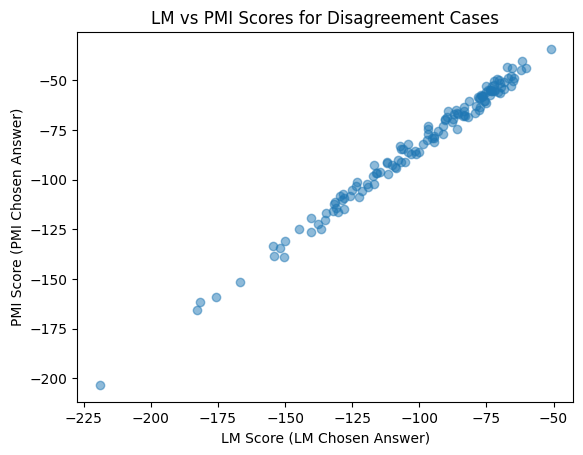

In [ ]:
plt.scatter(scatter_lm, scatter_pmi, alpha=0.5)

plt.xlabel("LM Score (LM Chosen Answer)")
plt.ylabel("PMI Score (PMI Chosen Answer)")
plt.title("LM vs PMI Scores for Disagreement Cases")

plt.show()

In [ ]:
lm_wrong_pmi_correct = []

for i in range(N):

    example = dataset[i]

    question = example["question"]
    choices = example["choices"]["text"]
    labels = example["choices"]["label"]
    correct = example["answerKey"]

    prompt = f"Question: {question}\nAnswer:"

    lm_scores = []
    unc_scores = []
    pmi_scores = []

    for ans in choices:
        lm = log_prob(prompt, ans)
        unc = log_prob("Answer:", ans)
        pmi = lm - unc

        lm_scores.append(lm)
        pmi_scores.append(pmi)

    lm_idx = np.argmax(lm_scores)
    pmi_idx = np.argmax(pmi_scores)

    if labels[lm_idx] != correct and labels[pmi_idx] == correct:
        lm_wrong_pmi_correct.append(question)

In [ ]:
lm_diffs = []
pmi_diffs = []

for i in range(N):

    example = dataset[i]

    question = example["question"]
    choices = example["choices"]["text"]

    prompt = f"Question: {question}\nAnswer:"

    lm_scores = []
    pmi_scores = []

    for ans in choices:
        lm = log_prob(prompt, ans)
        unc = log_prob("Answer:", ans)
        pmi = lm - unc

        lm_scores.append(lm)
        pmi_scores.append(pmi)

    lm_diffs.append(max(lm_scores) - sorted(lm_scores)[-2])
    pmi_diffs.append(max(pmi_scores) - sorted(pmi_scores)[-2])

In [ ]:
print("LM wrong but PMI correct questions:")
print(lm_wrong_pmi_correct)

print("LM score differences:")
print(lm_diffs)

print("PMI score differences:")
print(pmi_diffs)

In [ ]:
lm_wrong_pmi_correct = []

In [ ]:
lm_wrong_pmi_correct = []

for i in range(N):

    example = dataset[i]

    question = example["question"]
    choices = example["choices"]["text"]
    labels = example["choices"]["label"]
    correct = example["answerKey"]

    prompt = f"Question: {question}\nAnswer:"

    lm_scores = []
    unc_scores = []
    pmi_scores = []

    for ans in choices:

        lm = log_prob(prompt, ans)
        unc = log_prob("Answer:", ans)
        pmi = lm - unc

        lm_scores.append(lm)
        unc_scores.append(unc)
        pmi_scores.append(pmi)

    lm_idx = np.argmax(lm_scores)
    pmi_idx = np.argmax(pmi_scores)

    # ADD THIS PART
    if labels[lm_idx] != correct and labels[pmi_idx] == correct:
        lm_wrong_pmi_correct.append({
            "question": question,
            "choices": choices,
            "labels": labels,
            "correct": correct,
            "lm_choice": labels[lm_idx],
            "pmi_choice": labels[pmi_idx]
        })